In [ ]:
import pandas as pd

file_path = '/content/산불발생여부와_일별합계_지역정보추가_광역시통합.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,date,region_group,일별_합계,산불발생여부
0,2016-01-01,강원,0,0
1,2016-01-02,강원,0,0
2,2016-01-03,강원,0,0
3,2016-01-04,강원,0,0
4,2016-01-05,강원,0,0


In [ ]:
df.tail()

,date,region_group,일별_합계,산불발생여부
29587,2024-12-27,충남,0,0
29588,2024-12-28,충남,0,0
29589,2024-12-29,충남,0,0
29590,2024-12-30,충남,0,0
29591,2024-12-31,충남,0,0


In [ ]:
df.shape

(29592, 4)

## **결측치 확인**

In [ ]:
df.isnull().sum()

,0
date,0
region_group,0
일별_합계,0
산불발생여부,0


## **기초 통계 요약**

In [ ]:
df[['일별_합계', '산불발생여부']].describe()

,일별_합계,산불발생여부
count,29592.000000,29592.000000
mean,0.161327,0.110165
std,0.557826,0.313100
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,13.000000,1.000000


## **이상치 확인**

In [ ]:
q1 = df['일별_합계'].quantile(0.25)
q3 = df['일별_합계'].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 1.5 * iqr

outliers = df[df['일별_합계'] > outlier_threshold]
print("이상치 기준")
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, Threshold: {outlier_threshold}")
print(f"이상치 개수: {outliers.shape[0]}")

이상치 기준
Q1: 0.0, Q3: 0.0, IQR: 0.0, Threshold: 0.0
이상치 개수: 3260


일별 합게만 이상치로 확인하는 이유 = 연속형 값 <br>
산불 발생 여부도 이사이보단 비율,불균형 확인이 더 중요

<ipython-input-28-b26e9bf0cbaf>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


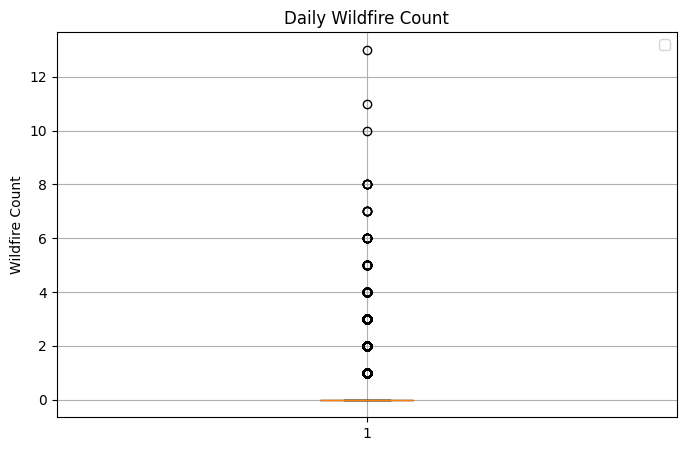

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df['일별_합계'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Daily Wildfire Count') # 일별 산불 건수
plt.ylabel('Wildfire Count') # 산불 발생 건수
plt.legend()
plt.grid(True)
plt.show()

붉은 점섬 -> 이상치 경계선<br>
0 ~ 8건 사이의 산불 발생은 상대적으로 고르게 분포가 되어있는데 9건 이상부터는 극단적인 이벤트로 생각할 수 있음

## **산불 발생 건수별 분포 시각화**

In [ ]:
value_distribution = df['일별_합계'].value_counts().sort_index()

In [ ]:
print(value_distribution)

일별_합계
0     26332
1      2326
2       605
3       197
4        75
5        28
6        15
7         5
8         6
10        1
11        1
13        1
Name: count, dtype: int64


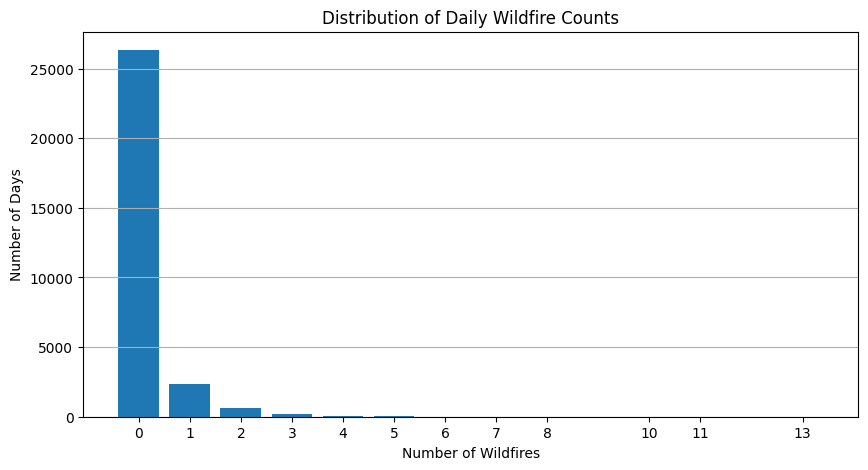

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(value_distribution.index, value_distribution.values)
plt.title('Distribution of Daily Wildfire Counts') # 산불 발생 건수별 일수 분포
plt.xlabel('Number of Wildfires') # 산불 발생 건수
plt.ylabel('Number of Days') # 일수(빈도)
plt.xticks(value_distribution.index)
plt.grid(axis='y')
plt.show()

In [ ]:
# 8건 이상 발생한 날만 필터링
df_over_8 = df[df['일별_합계'] >= 8]

# 날짜 및 지역 정보 출력
print("산불 8건 이상 발생한 날들의 날짜 및 지역:")
print(df_over_8[['date', 'region_group', '일별_합계']].sort_values('일별_합계', ascending=False))

산불 8건 이상 발생한 날들의 날짜 및 지역:
             date region_group  일별_합계
13594  2017-03-18        서울/경기     13
28952  2023-04-02           충남     11
15800  2023-04-02        서울/경기     10
7767   2019-04-06        대구/경북      8
13227  2016-03-16        서울/경기      8
13595  2017-03-19        서울/경기      8
13239  2016-03-28        서울/경기      8
15443  2022-04-10        서울/경기      8
15442  2022-04-09        서울/경기      8




---



In [ ]:
import pandas as pd

file_path = '/content/산불발생여부와_일별합계.csv'
df2 = pd.read_csv(file_path)

In [ ]:
df2.isnull().sum()

,0
date,0
일별_합계,0
산불발생여부,0


In [ ]:
q1 = df2['일별_합계'].quantile(0.25)
q3 = df2['일별_합계'].quantile(0.75)
iqr = q3 - q1
outlier_threshold = q3 + 1.5 * iqr

outliers = df2[df2['일별_합계'] > outlier_threshold]
print("이상치 기준")
print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, Threshold: {outlier_threshold}")
print(f"이상치 개수: {outliers.shape[0]}")

이상치 기준
Q1: 0.0, Q3: 2.0, IQR: 2.0, Threshold: 5.0
이상치 개수: 248


<ipython-input-4-459e8b733bae>:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


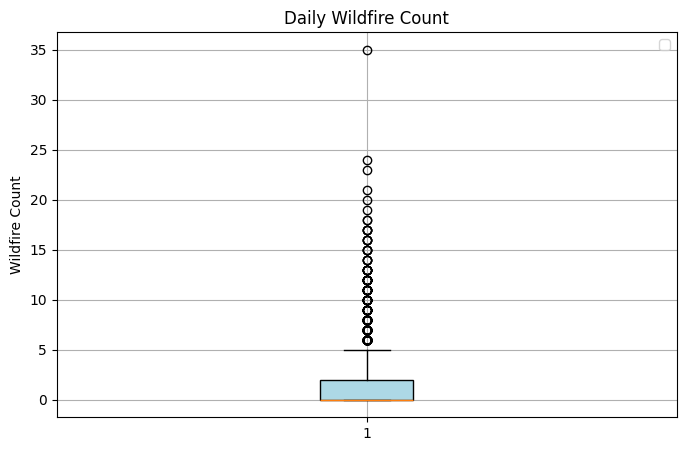

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df2['일별_합계'], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Daily Wildfire Count') # 일별 산불 건수
plt.ylabel('Wildfire Count') # 산불 발생 건수
plt.legend()
plt.grid(True)
plt.show()